In [1]:
import os
import duckdb

duckdb_path = os.getenv("DUCKDB_PATH")
assert duckdb_path is not None, "Variable 'DUCKDB_PATH' must be defined"

con = duckdb.connect(duckdb_path)
con.sql("SELECT * FROM INFORMATION_SCHEMA.TABLES;").df()

,table_catalog,table_schema,table_name,table_type,self_referencing_column_name,reference_generation,user_defined_type_catalog,user_defined_type_schema,user_defined_type_name,is_insertable_into,is_typed,commit_action,TABLE_COMMENT
0,legislative,main,deputados,BASE TABLE,None,None,None,None,None,YES,NO,None,None
1,legislative,main,proposicoesTemas,BASE TABLE,None,None,None,None,None,YES,NO,None,None
2,legislative,main,votacoesObjetos,BASE TABLE,None,None,None,None,None,YES,NO,None,None
3,legislative,main,votacoesVotos,BASE TABLE,None,None,None,None,None,YES,NO,None,None
4,legislative,main,deputies_propositions,VIEW,None,None,None,None,None,NO,NO,None,None


In [5]:
con.sql('SELECT COUNT(*) FROM deputados')

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│         7883 │
└──────────────┘

In [3]:
dp_view_list = con.sql("SELECT * FROM INFORMATION_SCHEMA.VIEWS WHERE table_name = 'deputies_propositions';")

def create_deputies_propositions_view():
    query = open("../queries/deputies_propositions.sql").read()
    con.execute(f"CREATE OR REPLACE VIEW deputies_propositions AS {query}")

if (not dp_view_list.shape[0] > 0):
    create_deputies_propositions_view()

dp_view = con.sql("SELECT * FROM deputies_propositions;")
dp_view

┌───────────────┬─────────────┬─────────┐
│ proposicao_id │ deputado_id │  voto   │
│    varchar    │   varchar   │ varchar │
├───────────────┼─────────────┼─────────┤
│ p_2574728     │ d_204549    │ Sim     │
│ p_2574728     │ d_73579     │ Sim     │
│ p_2574728     │ d_220538    │ Sim     │
│ p_2574728     │ d_160559    │ Sim     │
│ p_2574728     │ d_204501    │ Sim     │
│ p_2574728     │ d_204571    │ Sim     │
│ p_2574728     │ d_220542    │ Sim     │
│ p_2574728     │ d_221148    │ Sim     │
│ p_2574728     │ d_220576    │ Não     │
│ p_2574728     │ d_74057     │ Sim     │
│     ·         │    ·        │  ·      │
│     ·         │    ·        │  ·      │
│     ·         │    ·        │  ·      │
│ p_2416456     │ d_204356    │ Sim     │
│ p_2416456     │ d_220715    │ Sim     │
│ p_2416456     │ d_107970    │ Sim     │
│ p_2416456     │ d_220556    │ Sim     │
│ p_2416456     │ d_220632    │ Sim     │
│ p_2416456     │ d_220657    │ Não     │
│ p_2416456     │ d_133439    │ Si

In [3]:
con.sql("DROP VIEW IF EXISTS deputies_propositions;")

In [14]:
deputies_polls_query = open("../queries/deputies_polls.sql").read()

dpl_view_count = con.sql(f"SELECT COUNT(*) FROM ({deputies_polls_query})")
dpl_view_count

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│       412535 │
└──────────────┘

## Votos dos Deputados por Tema

In [5]:
con.sql("SELECT DISTINCT codTema, tema FROM proposicoesTemas ORDER BY codTema")

┌─────────┬─────────────────────────────────────────────┐
│ codTema │                    tema                     │
│  int64  │                   varchar                   │
├─────────┼─────────────────────────────────────────────┤
│      34 │ Administração Pública                       │
│      35 │ Arte, Cultura e Religião                    │
│      37 │ Comunicações                                │
│      39 │ Esporte e Lazer                             │
│      40 │ Economia                                    │
│      41 │ Cidades e Desenvolvimento Urbano            │
│      42 │ Direito Civil e Processual Civil            │
│      43 │ Direito Penal e Processual Penal            │
│      44 │ Direitos Humanos e Minorias                 │
│      46 │ Educação                                    │
│       · │    ·                                        │
│       · │    ·                                        │
│       · │    ·                                        │
│      64 │ Ag

In [6]:
deputies_polls_themes_query = open("../queries/deputies_polls_themes.sql").read()

In [6]:
def query_votes_by_theme(theme_code: int):
    return con.execute(deputies_polls_themes_query, [theme_code]).df()

In [7]:
theme_votes = query_votes_by_theme(41)
theme_votes

,deputado_id,votacao_id,voto
0,d_220593,v_2345484-83,Sim
1,d_204379,v_2345484-83,Não
2,d_221328,v_2345484-83,Sim
3,d_204528,v_2345484-83,Não
4,d_121948,v_2345484-83,Não
...,...,...,...
347,d_220536,v_2345484-83,Não
348,d_160632,v_2345484-83,Não
349,d_220558,v_2345484-83,Sim
350,d_220592,v_2345484-83,Não


In [2]:
deputies_votes_grouped_themes_query = open("../queries/deputies_votes_grouped_themes.sql").read()

In [3]:
def query_votes_by_grouped_themes(theme_codes: list[int]):
    return con.execute(deputies_votes_grouped_themes_query, [theme_codes]).df()

In [4]:
themes = [34, 40]

grouped_theme_votes = query_votes_by_grouped_themes(themes)
grouped_theme_votes

,deputado_id,votacao_id,voto
0,d_204379,v_2519886-21,Não
1,d_220714,v_2519886-21,Não
2,d_221328,v_2519886-21,Sim
3,d_204560,v_2519886-21,Não
4,d_204528,v_2519886-21,Não
...,...,...,...
18813,d_220536,v_2498090-47,Não
18814,d_160632,v_2498090-47,Sim
18815,d_220558,v_2498090-47,Não
18816,d_160592,v_2498090-47,Não


In [5]:
import networkx as nx
from matplotlib import pyplot as plt
import statistics

In [6]:
G = nx.from_pandas_edgelist(grouped_theme_votes, source='deputado_id', target='votacao_id', edge_attr='voto')

In [13]:
nx.number_of_nodes(G)

632

In [14]:
nx.number_of_edges(G)

18818

(array([64., 63., 63., 63., 63., 63., 63., 63., 63., 64.]),
 array([  0. ,  63.1, 126.2, 189.3, 252.4, 315.5, 378.6, 441.7, 504.8,
        567.9, 631. ]),
 <BarContainer object of 10 artists>)

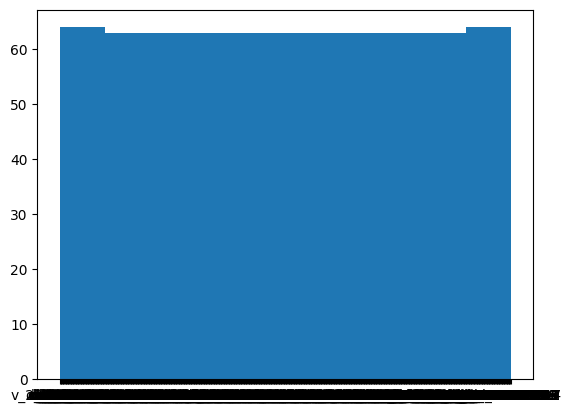

In [15]:
degrees = dict(G.degree())
plt.hist(degrees)

In [16]:
avg_degree = sum(degrees.values()) / len(degrees)
avg_degree

59.550632911392405

In [17]:
nx.number_connected_components(G)

1

In [10]:
deputies_nodes, polls_nodes = nx.bipartite.sets(G)

In [13]:
len(deputies_nodes)

583

In [14]:
len(polls_nodes)

49

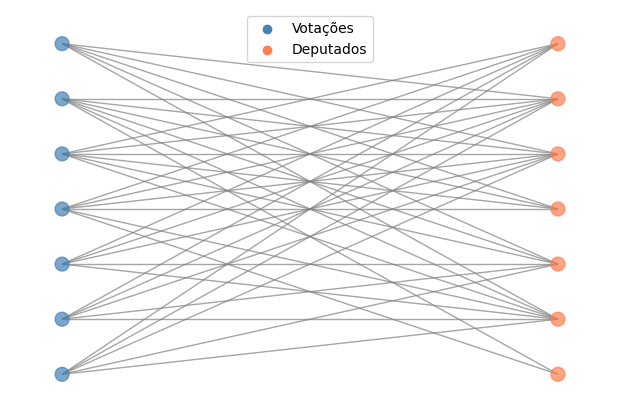

In [31]:
sample_polls = list(polls_nodes)[:7]
sample_nodes = set(sample_polls)
for poll in sample_polls:
    sample_nodes.update(list(G.neighbors(poll))[:5])

subgrafo = G.subgraph(sample_nodes)
pos = nx.bipartite_layout(subgrafo, sample_polls, scale=0.2)

node_colors = [
    "steelblue" if node in polls_nodes else "coral"
    for node in subgrafo.nodes()
]

plt.figure(figsize=(6, 4))
nx.draw(
    subgrafo,
    pos=pos,
    node_color=node_colors,
    with_labels=False,
    node_size=100,
    edge_color="gray",
    alpha=0.7
)

plt.legend(
    handles=[
        plt.scatter([], [], color="steelblue", label="Votações"),
        plt.scatter([], [], color="coral", label="Deputados")
    ],
    loc="upper center"
)
# plt.title("Estrutura do grafo bipartido (amostra)")
plt.show()

Text(0, 0.5, 'Número de deputados')

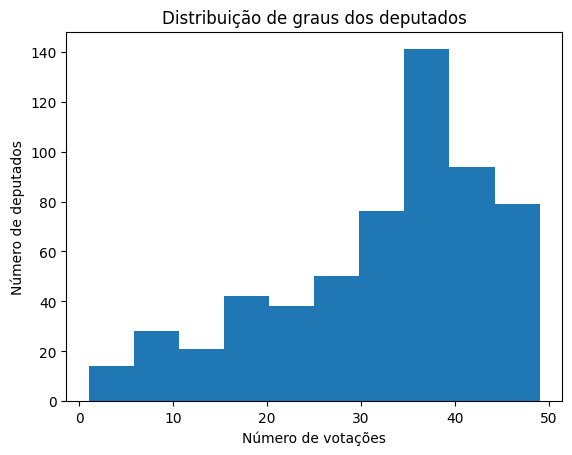

In [11]:
deputy_degrees = [G.degree(n) for n in deputies_nodes]
plt.hist(deputy_degrees)sample_polls = list(polls_nodes)[:7]
sample_nodes = set(sample_polls)
for poll in sample_polls:
    sample_nodes.update(list(G.neighbors(poll))[:5])

subgrafo = G.subgraph(sample_nodes)
pos = nx.bipartite_layout(subgrafo, sample_polls)

node_colors = [
    "steelblue" if node in polls_nodes else "coral"
    for node in subgrafo.nodes()
]

plt.figure(figsize=(8, 4))
nx.draw(
    subgrafo,
    pos=pos,
    node_color=node_colors,
    with_labels=False,
    node_size=100,
    edge_color="gray",
    alpha=0.7
)

plt.legend(
    handles=[
        plt.scatter([], [], color="steelblue", label="Votações"),
        plt.scatter([], [], color="coral", label="Deputados")
    ],
    loc="upper right"
)
plt.title("Estrutura do grafo bipartido (amostra)")
plt.show()
plt.title("Distribuição de graus dos deputados")
plt.xlabel("Número de votações")
plt.ylabel("Número de deputados")

In [13]:
d_avg_degree = sum(deputy_degrees) / len(deputy_degrees)
d_avg_degree

32.2778730703259

In [14]:
d_median_degree = statistics.median(deputy_degrees)
d_median_degree

35

In [15]:
statistics.stdev(deputy_degrees)

11.635130516460222

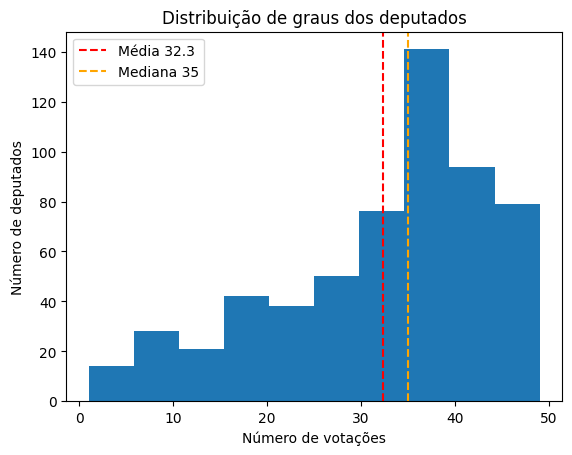

In [16]:
plt.hist(deputy_degrees)
plt.title("Distribuição de graus dos deputados")
plt.xlabel("Número de votações")
plt.ylabel("Número de deputados")
plt.axvline(d_avg_degree, color='red', linestyle='dashed', label=f'Média {d_avg_degree:.1f}')
plt.axvline(d_median_degree, color='orange', linestyle='dashed', label=f'Mediana {d_median_degree}')
plt.legend()

Text(0, 0.5, 'Número de deputados')

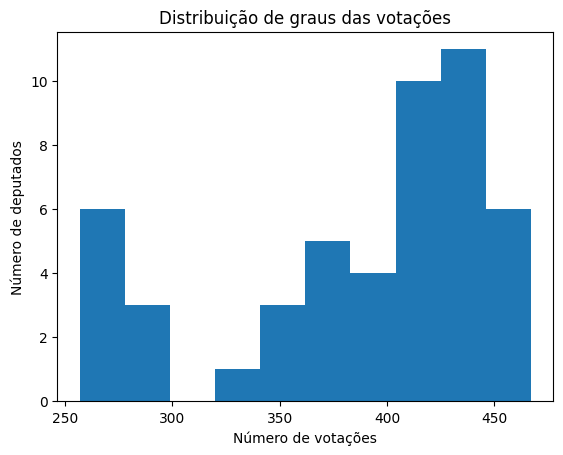

In [25]:
poll_degrees = [G.degree(n) for n in polls_nodes]
plt.hist(poll_degrees)
plt.title("Distribuição de graus das votações")
plt.xlabel("Número de votações")
plt.ylabel("Número de deputados")

In [30]:
p_avg_degree = sum(poll_degrees) / len(poll_degrees)
p_avg_degree

384.0408163265306

In [31]:
p_median_degree = statistics.median(poll_degrees)
p_median_degree

409

In [41]:
statistics.stdev(poll_degrees)

63.2863726720563

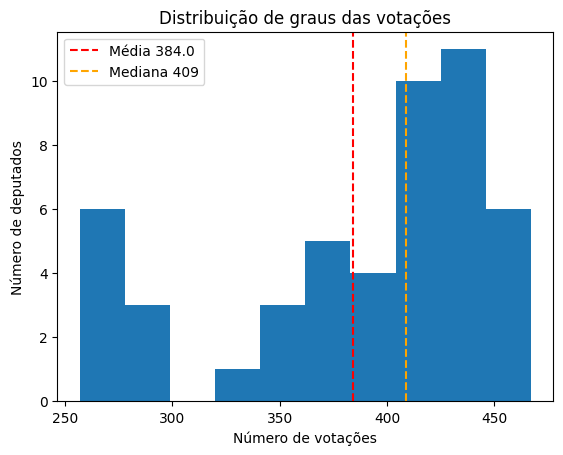

In [39]:
plt.hist(poll_degrees)
plt.title("Distribuição de graus das votações")
plt.xlabel("Número de votações")
plt.ylabel("Número de deputados")
plt.axvline(p_avg_degree, color='red', linestyle='dashed', label=f'Média {p_avg_degree:.1f}')
plt.axvline(p_median_degree, color='orange', linestyle='dashed', label=f'Mediana {p_median_degree}')
plt.legend()

In [17]:
nx.write_gexf(G, '../graphs/deputy_votes.gefx')